# Classic CNN (ResNet) - Model, Make Prediction

### Imports

In [11]:
from collections import defaultdict
from torch.utils.data import Subset
import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from PIL import Image
import os
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torch.utils.data import random_split
from torchvision import datasets
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import re
import random

### VMMRdb Download

In [5]:
path = kagglehub.dataset_download("prabashwara/vmmrdb-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.5G/11.5G [12:41<00:00, 16.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prabashwara/vmmrdb-dataset/versions/1


### Custom Pytorch Dataset Definition

In [2]:
class VMMRDB_Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}

        # Unique classes
        unique_classes = set()
        for class_name in sorted(os.listdir(root_dir)):
          class_path = os.path.join(root_dir, class_name)
          if os.path.isdir(class_path):
            stripped = re.sub(r'_\d{4}$', '', class_name)
            unique_classes.add(stripped)

        # Indicies to unique class names
        for idx, class_name in enumerate(sorted(unique_classes)):
          self.class_to_idx[class_name] = idx

        # Images to class names
        for class_name in sorted(os.listdir(root_dir)):
          class_path = os.path.join(root_dir, class_name)
          if os.path.isdir(class_path):
            stripped = re.sub(r'_\d{4}$', '', class_name)
            idx = self.class_to_idx[stripped]
            for img_name in os.listdir(class_path):
              if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

### Calculating Mean and Standard Deviation for Normalization

Don't run, this is just the code I ran to get the mean and std used in the image transform

In [ ]:
# Creating dataloader
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
dataset = VMMRDB_Dataset(path, transform=transform)
data_loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)

In [ ]:
# Mean and Standard Deviation Calculation

mean = 0
ex2 = 0
total_pixels = 0

loop = tqdm(data_loader)
for images, _ in loop:
    B, C, H, W = images.shape

    images = images.view(B, C, -1) # H x W

    mean += images.sum(dim=(0, 2))
    ex2 += (images ** 2).sum(dim=(0, 2))

    total_pixels += B * H * W

    loop.set_description("mean + std calculation")

mean /= total_pixels
ex2 /= total_pixels

std = torch.sqrt(ex2 - mean ** 2)

print()
print("Mean:", mean)
print("Std:", std)

### ResNet 18 Architecture

In [3]:
class BasicBlock(nn.Module):
  def __init__(self, in_channel, out_channel, stride=1):
    super(BasicBlock, self).__init__()

    # First convolution
    self.conv1 = nn.Conv2d(in_channel, out_channel, kernel_size=3, padding=1, stride=stride, bias=False)
    self.batch_norm1 = nn.BatchNorm2d(out_channel)

    # Second Convolution
    self.conv2 = nn.Conv2d(out_channel, out_channel, kernel_size=3, stride=1, padding=1, bias=False)
    self.batch_norm2 = nn.BatchNorm2d(out_channel)

    # Skip Connection
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channel != out_channel:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channel, out_channel, kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channel)
      )

    self.relu = nn.ReLU(inplace=True)

  def forward(self, x):
    out = self.relu(self.batch_norm1(self.conv1(x)))
    out = self.batch_norm2(self.conv2(out))
    out += self.shortcut(x)
    out = self.relu(out)
    return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()

        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet layers
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = []

        # First block
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels

        # Remaining blocks
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution step
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        # ResNet Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Fully connected portion
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def ResNet18(num_classes):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

### Training and Testing Dataset

In [8]:
# batch size
batch_size = 512

# Defines image preprocessing for the training and test datasets
train_transform = transforms.Compose([
    transforms.Resize((224,224)),

    # Random Transformations
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomRotation(10),

    transforms.ToTensor(),
    transforms.Normalize([0.4367, 0.4331, 0.4279], [0.2685, 0.2652, 0.2675])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.4367, 0.4331, 0.4279], [0.2685, 0.2652, 0.2675])
])

# Creates test and train dataset by limiting the number of images per class
dataset_VMMRDB = VMMRDB_Dataset(path, transform=train_transform)
train_size = int(0.8 * len(dataset_VMMRDB))
test_size = len(dataset_VMMRDB) - train_size

# Reproducible split
generator = torch.Generator().manual_seed(0)
dataset_train, dataset_test = random_split(dataset_VMMRDB, [train_size, test_size], generator=generator)

# Modify testing dataset transform
dataset_test.dataset.transform = test_transform

# Creates the train and test loaders
train_loader = DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### Training Step

In [ ]:
# Defines CNN, loss and optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
net = ResNet18(num_classes=len(dataset_VMMRDB.class_to_idx)).to(device)
loss_criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Number of iterations over dataset
epochs = 20

checkpoint_path = "./checkpoint.pth"
start_epoch = 0

# Trying to load trained weights
try:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    net.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {start_epoch}")
except:
    print("No checkpoint found, starting fresh.")

# Training loop
epoch_losses = []
log_file = "training.log"
with open(log_file, "a") as f:
  f.write("Training Started")

for epoch in range(start_epoch, epochs):
  running_loss = 0
  num_batches = 0
  loop = tqdm(train_loader, leave=True)

  for X, y in loop:
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    output = net(X)

    loss = loss_criterion(output, y)
    running_loss += loss.item()
    num_batches += 1

    loss.backward()
    optimizer.step()

    loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
    loop.set_postfix(loss=loss.item())

  epoch_losses.append(running_loss / num_batches)
  print(f"Epoch {epoch+1} finished. Avg Loss: {epoch_losses[-1]}")

  with open(log_file, "a") as f:
    f.write(f"Epoch {epoch+1} finished. Avg Loss: {epoch_losses[-1]}\n")
checkpoint = {
    "epoch": epoch,
    "model_state": net.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "loss": epoch_losses[-1]
}
torch.save(checkpoint, checkpoint_path)

No checkpoint found, starting fresh.


Epoch [1/20]: 100%|██████████| 446/446 [11:01<00:00,  1.48s/it, loss=3.31]


Epoch 1 finished. Avg Loss: 4.526220433915142


Epoch [2/20]:  16%|█▌        | 72/446 [01:46<08:02,  1.29s/it, loss=3.16]

### Load Model and Evaluating

In [ ]:
# Loading model
device = "cuda" if torch.cuda.is_available() else "cpu"
net = ResNet18(num_classes=len(dataset_VMMRDB.class_to_idx)).to(device)
try:
  test_path = "./test_resnet18.pth"
  test = torch.load(test_path)
  net.load_state_dict(test["model_state"])
except:
    print("No save found")

In [ ]:
correct = 0
total = 0

# Test loop
net.eval()
with torch.no_grad():
    loop = tqdm(test_loader, leave=True)
    for X, y in loop:
        X = X.to(device)
        y = y.to(device)

        outputs = net(X)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == y).sum().item()
        total += y.size(0)
        acc = correct / total

        loop.set_description("Evaluating")
        loop.set_postfix(acc=acc)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating: 100%|██████████| 112/112 [03:16<00:00,  1.76s/it, acc=0.711]

Test Accuracy: 0.7112


## Plotting Trainig Loss vs Epoch

In [13]:
plt.plot(range(len(epoch_losses)), epoch_losses)
plt.title("Training Loss vs Epoch")
plt.ylabel("Loss")
plt.xlabel("Epoch")

### Predict From Random Image in Test Dataset

Prediction: chevrolet_blazer
Actual chevrolet_blazer
Confidence: 0.9503


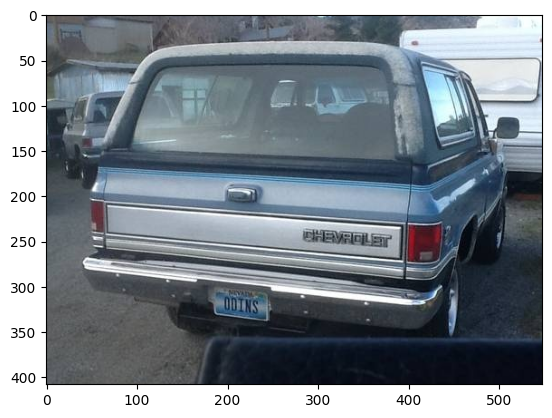

In [37]:
def predict_random_image(dataset, model, transform, class_to_idx, device):
    model.eval()

    # Pick random image
    idx = random.randint(0, len(dataset.image_paths) - 1)
    image_path = dataset.image_paths[idx]

    # Load and preprocess
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    image = transform(image)
    image = image.unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    # Index → class name
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    predicted_class = idx_to_class[predicted.item()]

    print(f"Prediction: {predicted_class}")
    print(f"Actual {idx_to_class[dataset.labels[idx]]}")
    print(f"Confidence: {confidence.item():.4f}")
    return image_path, predicted_class, confidence.item()

# Run it
predict_random_image(
    dataset_test.dataset,
    net,
    test_transform,
    dataset_VMMRDB.class_to_idx,
    device
)
None